Hipparcos data loaded: 117955 stars
VIIRS raster loaded: width=86401, height=33601
Processed Delhi, India: Radiance=152.870, Limiting Mag=2.5, Visible Stars=1
Processed Hanle, India (Dark Site): Radiance=0.470, Limiting Mag=6.0, Visible Stars=27
Processed Beijing, China: Radiance=103.750, Limiting Mag=2.5, Visible Stars=0
Processed Ngari, China (Dark Site): Radiance=86.210, Limiting Mag=3.5, Visible Stars=2
Processed Cape Town, South Africa: Radiance=86.300, Limiting Mag=3.5, Visible Stars=0
Processed Sutherland, South Africa (Dark Site): Radiance=0.410, Limiting Mag=6.0, Visible Stars=12
Processed São Paulo, Brazil: Radiance=165.270, Limiting Mag=2.5, Visible Stars=0
Processed Chapada, Brazil (Dark Site): Radiance=0.260, Limiting Mag=6.0, Visible Stars=19
Processed Moscow, Russia: Radiance=594.850, Limiting Mag=2.5, Visible Stars=0
Processed Lake Baikal, Russia (Dark Site): Radiance=0.000, Limiting Mag=6.5, Visible Stars=25

City-wise star visibility summary:
                         

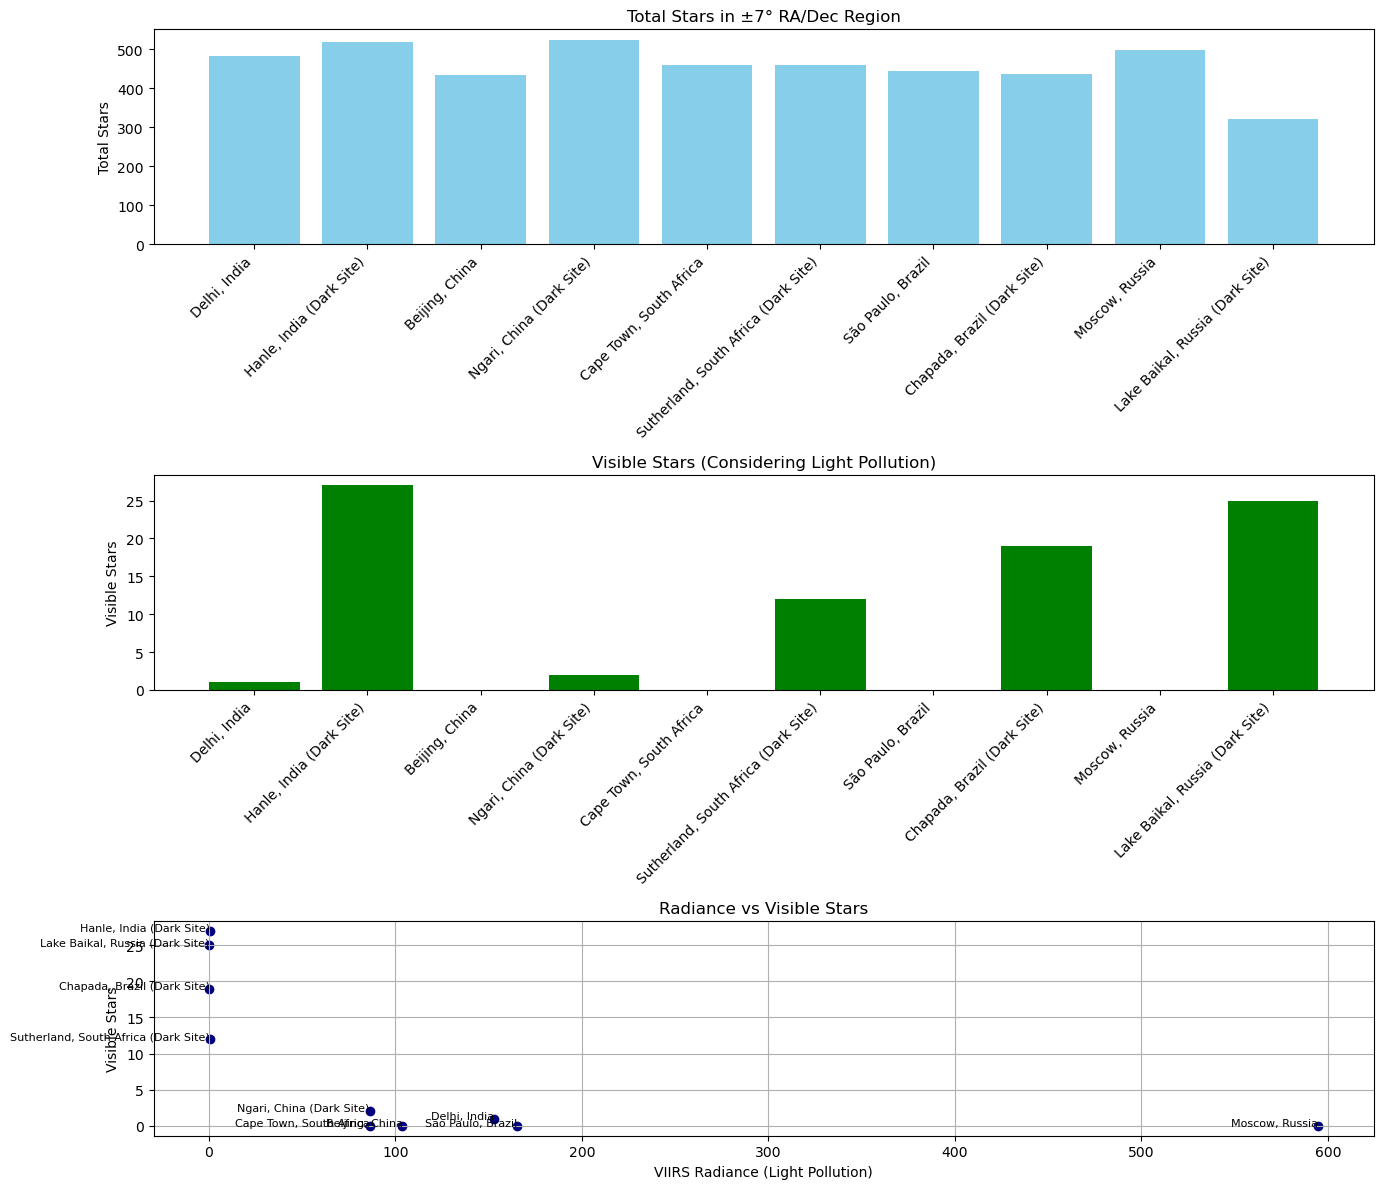

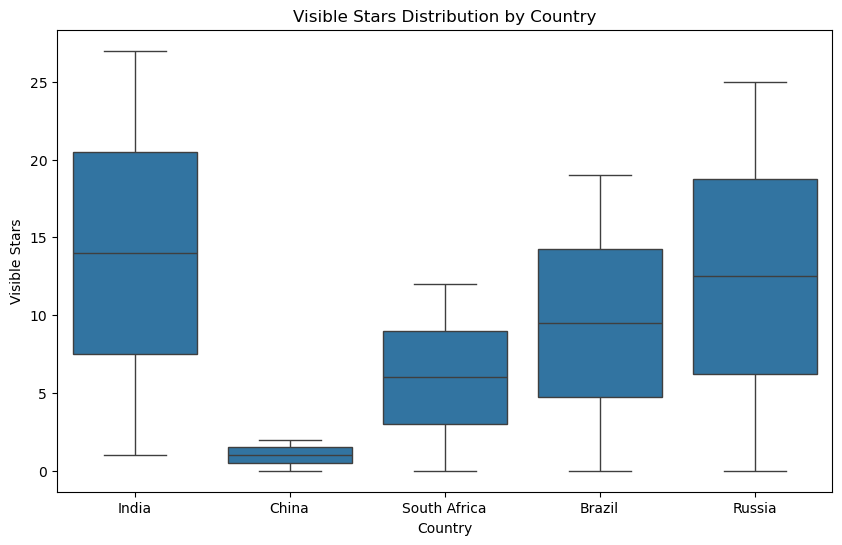


Total execution time: 235.26 seconds


In [3]:
import pandas as pd
import numpy as np
import rasterio
import matplotlib.pyplot as plt
import seaborn as sns
import time

# --- Start timer ---
start_time = time.time()

# --- File paths ---
hip_path =  r"C:\\Users\\nischaya jajodia\\OneDrive\\Desktop\\Brics captonee\\hip_main.dat"
viirs_path =  r"C:\\Users\\nischaya jajodia\\OneDrive\\Desktop\\Brics captonee\\SVDNB_npp_20250201-20250228_global_vcmcfg_v10_c202503122200.avg_rade9h.tif"

# --- Load Hipparcos data ---
colspecs = [(51, 63), (64, 76), (41, 46)]  # RA, Dec, Vmag
colnames = ['ra', 'dec', 'mag']
hip_df = pd.read_fwf(hip_path, colspecs=colspecs, names=colnames)
hip_df = hip_df.apply(pd.to_numeric, errors='coerce')
hip_df.dropna(inplace=True)
print(f"Hipparcos data loaded: {hip_df.shape[0]} stars")

# --- Load VIIRS raster ---
raster = rasterio.open(viirs_path)
print(f"VIIRS raster loaded: width={raster.width}, height={raster.height}")

# --- Function to estimate limiting magnitude from radiance ---
def estimate_limiting_mag(radiance):
    if radiance < 0.25:
        return 6.5
    elif radiance < 5:
        return 6.0
    elif radiance < 20:
        return 5.0
    elif radiance < 50:
        return 4.5
    elif radiance < 100:
        return 3.5
    else:
        return 2.5

# --- Cities and country grouping ---
cities = {
    "Delhi, India": (77.2090, 28.6139),
    "Hanle, India (Dark Site)": (78.9, 32.8),
    "Beijing, China": (116.4074, 39.9042),
    "Ngari, China (Dark Site)": (80.1, 32.5),
    "Cape Town, South Africa": (18.4241, -33.9249),
    "Sutherland, South Africa (Dark Site)": (20.8, -32.4),
    "São Paulo, Brazil": (-46.6333, -23.5505),
    "Chapada, Brazil (Dark Site)": (-47.7, -14.1),
    "Moscow, Russia": (37.6173, 55.7558),
    "Lake Baikal, Russia (Dark Site)": (108.2, 53.6),
}

country_map = {
    "Delhi, India": "India",
    "Hanle, India (Dark Site)": "India",
    "Beijing, China": "China",
    "Ngari, China (Dark Site)": "China",
    "Cape Town, South Africa": "South Africa",
    "Sutherland, South Africa (Dark Site)": "South Africa",
    "São Paulo, Brazil": "Brazil",
    "Chapada, Brazil (Dark Site)": "Brazil",
    "Moscow, Russia": "Russia",
    "Lake Baikal, Russia (Dark Site)": "Russia",
}

results = []

# --- Process each city ---
for city, (lon, lat) in cities.items():
    try:
        row, col = raster.index(lon, lat)
        radiance = raster.read(1)[row, col]
        lim_mag = estimate_limiting_mag(radiance)

        ra_center = lon % 360
        ra_min = (ra_center - 7) % 360
        ra_max = (ra_center + 7) % 360
        dec_min = lat - 7
        dec_max = lat + 7

        if ra_min < ra_max:
            ra_filter = (hip_df['ra'] >= ra_min) & (hip_df['ra'] <= ra_max)
        else:
            ra_filter = (hip_df['ra'] >= ra_min) | (hip_df['ra'] <= ra_max)
        dec_filter = (hip_df['dec'] >= dec_min) & (hip_df['dec'] <= dec_max)

        nearby_stars = hip_df[ra_filter & dec_filter]
        visible_stars = nearby_stars[nearby_stars['mag'] <= lim_mag]

        results.append({
            "city": city,
            "country": country_map[city],
            "radiance": radiance,
            "limiting_mag": lim_mag,
            "total_stars": len(nearby_stars),
            "visible_stars": len(visible_stars)
        })
        print(f"Processed {city}: Radiance={radiance:.3f}, Limiting Mag={lim_mag}, Visible Stars={len(visible_stars)}")

    except Exception as e:
        print(f"Error processing {city}: {e}")
        results.append({
            "city": city,
            "country": country_map.get(city, "Unknown"),
            "radiance": None,
            "limiting_mag": None,
            "total_stars": 0,
            "visible_stars": 0
        })

# --- Convert results to DataFrame ---
results_df = pd.DataFrame(results)

# --- Print summary table ---
print("\nCity-wise star visibility summary:")
print(results_df[['city', 'radiance', 'limiting_mag', 'total_stars', 'visible_stars']])

# --- Plotting ---
plt.figure(figsize=(14, 12))

# Bar chart 1: Total stars
plt.subplot(3, 1, 1)
plt.bar(results_df['city'], results_df['total_stars'], color='skyblue')
plt.title('Total Stars in ±7° RA/Dec Region')
plt.ylabel('Total Stars')
plt.xticks(rotation=45, ha='right')

# Bar chart 2: Visible stars
plt.subplot(3, 1, 2)
plt.bar(results_df['city'], results_df['visible_stars'], color='green')
plt.title('Visible Stars (Considering Light Pollution)')
plt.ylabel('Visible Stars')
plt.xticks(rotation=45, ha='right')

# Scatter plot: Radiance vs visible stars
plt.subplot(3, 1, 3)
valid_mask = results_df['radiance'].notna()
plt.scatter(results_df.loc[valid_mask, 'radiance'], results_df.loc[valid_mask, 'visible_stars'], color='navy')

for i, row in results_df[valid_mask].iterrows():
    plt.text(row['radiance'], row['visible_stars'], row['city'], fontsize=8, ha='right')

plt.xlabel('VIIRS Radiance (Light Pollution)')
plt.ylabel('Visible Stars')
plt.title('Radiance vs Visible Stars')
plt.grid(True)

plt.tight_layout()
plt.show()

# --- Boxplot: Visible stars by country ---
plt.figure(figsize=(10,6))
sns.boxplot(x='country', y='visible_stars', data=results_df)
plt.title('Visible Stars Distribution by Country')
plt.ylabel('Visible Stars')
plt.xlabel('Country')
plt.show()

# --- Execution time ---
end_time = time.time()
print(f"\nTotal execution time: {end_time - start_time:.2f} seconds")
